# Model Results Analysis

Gather and analyze results from all ML models, comparing R² scores and squared Pearson correlation coefficients with statistical significance indicators.

## 1. Import Required Libraries

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## 2. Load Results from Folder

In [13]:
# Define results folder path
results_folder = './results'

# Recursively find all JSON files in results folder
result_files = glob.glob(os.path.join(results_folder, '**', '*.json'), recursive=True)

print(f"Found {len(result_files)} result files")
for f in sorted(result_files):
    print(f"  {f}")

# Load all results
all_results = []
for result_file in sorted(result_files):
    try:
        with open(result_file, 'r') as f:
            data = json.load(f)
            # Extract model name and folder info
            folder_name = os.path.basename(os.path.dirname(result_file))
            file_name = os.path.basename(result_file)
            
            # Parse model name from folder (e.g., 'lasso_regression_SCZ_p0.0001_low_1_1')
            parts = folder_name.split('_')
            if 'residual' in parts[0]:
                model_name = 'residual_dnn'
                model_short = 'DNN'
            elif 'linear' in parts[0]:
                model_name = 'linear_regression'
                model_short = 'OLS'
            else:
                model_name = parts[0] + ('_' + parts[1] if len(parts) > 1 and parts[1] in ['regression', 'dnn'] else '')
                model_short = {
                    'lasso_regression': 'Lasso',
                    'ridge_regression': 'Ridge',
                    'xgboost': 'XGBoost',
                    'tabpfn': 'TabPFN'
                }.get(model_name, model_name)
            
            all_results.append({
                'folder': folder_name,
                'file': file_name,
                'model': model_name,
                'model_short': model_short,
                'data': data
            })
    except Exception as e:
        print(f"Error loading {result_file}: {e}")

print(f"\nLoaded {len(all_results)} results")
for r in all_results:
    print(f"  {r['model_short']:20s} - {r['folder']}")

Found 6 result files
  ./results/lasso_regression_SCZ_p0.0001_low_1_1/lasso_regression_SCZ_p0.0001_low_1_1_20260518_000545.json
  ./results/linear_regression_SCZ_p0.0001_low_0.4_0.5/linear_regression_SCZ_p0.0001_low_0.4_0.5_20260518_000331.json
  ./results/residual_dnn_SCZ_p0.0001_low_1_1/residual_dnn_SCZ_p0.0001_low_1_1_20260518_000113.json
  ./results/ridge_regression_SCZ_p0.0001_low_1_1/ridge_regression_SCZ_p0.0001_low_1_1_20260518_000401.json
  ./results/tabpfn_SCZ_p0.0001_low_1_1/tabpfn_SCZ_p0.0001_low_20260423_024320.json
  ./results/xgboost_SCZ_p0.0001_low_1_1/xgboost_SCZ_p0.0001_low_1_1_20260518_000231.json

Loaded 6 results
  Lasso                - lasso_regression_SCZ_p0.0001_low_1_1
  OLS                  - linear_regression_SCZ_p0.0001_low_0.4_0.5
  DNN                  - residual_dnn_SCZ_p0.0001_low_1_1
  Ridge                - ridge_regression_SCZ_p0.0001_low_1_1
  TabPFN               - tabpfn_SCZ_p0.0001_low_1_1
  XGBoost              - xgboost_SCZ_p0.0001_low_1_1


## 3. Extract R² and Squared Pearson Correlation Scores

In [14]:
# Extract R2 scores and Pearson r2 scores from HPO results
extracted_data = []

for result in all_results:
    model_data = result['data']
    
    # Extract from HPO results
    if 'hpo' in model_data:
        hpo = model_data['hpo']
        
        # Get R2 scores
        r2_scores = hpo.get('r2_scores', [])
        
        # Get Pearson r2 scores (squared correlation)
        pearson_r2_scores = hpo.get('pearson_r2_scores', [])
        
        # Clean NaN values from scores
        r2_clean = [x for x in r2_scores if not (isinstance(x, float) and np.isnan(x))]
        pearson_r2_clean = [x for x in pearson_r2_scores if not (isinstance(x, float) and np.isnan(x))]
        
        # Add each fold's data as separate row for boxplot
        for i, r2 in enumerate(r2_scores):
            if not (isinstance(r2, float) and np.isnan(r2)):
                pearson_r2 = pearson_r2_scores[i] if i < len(pearson_r2_scores) else np.nan
                if not (isinstance(pearson_r2, float) and np.isnan(pearson_r2)):
                    extracted_data.append({
                        'Model': result['model_short'],
                        'Model_Full': result['model'],
                        'Fold': i + 1,
                        'R2': r2,
                        'Pearson_R2': pearson_r2,
                        'File': result['file']
                    })

# Create DataFrame
df_scores = pd.DataFrame(extracted_data)

print(f"Extracted {len(df_scores)} fold results from {len(all_results)} files")
print(f"\nUnique models: {df_scores['Model'].unique()}")
print(f"\nDataFrame shape: {df_scores.shape}")
print(f"\nFirst few rows:")
print(df_scores.head(10))

Extracted 30 fold results from 6 files

Unique models: <ArrowStringArray>
['Lasso', 'OLS', 'DNN', 'Ridge', 'TabPFN', 'XGBoost']
Length: 6, dtype: str

DataFrame shape: (30, 6)

First few rows:
   Model         Model_Full  Fold        R2  Pearson_R2  \
0  Lasso   lasso_regression     1  0.061734    0.063629   
1  Lasso   lasso_regression     2 -0.000978    0.000000   
2  Lasso   lasso_regression     3 -0.010862    0.000000   
3  Lasso   lasso_regression     4 -0.002260    0.000000   
4  Lasso   lasso_regression     5 -0.004871    0.002429   
5    OLS  linear_regression     1 -6.531507    0.000015   
6    OLS  linear_regression     2 -5.506722    0.011880   
7    OLS  linear_regression     3 -7.592827    0.005082   
8    OLS  linear_regression     4 -5.490901    0.046438   
9    OLS  linear_regression     5 -5.609398    0.047124   

                                                File  
0  lasso_regression_SCZ_p0.0001_low_1_1_20260518_...  
1  lasso_regression_SCZ_p0.0001_low_1_1_2026051

## 4. Calculate Mean and Standard Deviation

In [15]:
# Calculate summary statistics for each model
summary_stats = []

for model in sorted(df_scores['Model'].unique()):
    model_data = df_scores[df_scores['Model'] == model]
    
    r2_values = model_data['R2'].values
    pearson_r2_values = model_data['Pearson_R2'].values
    
    summary_stats.append({
        'Model': model,
        'N_Folds': len(r2_values),
        'R2_Mean': r2_values.mean(),
        'R2_Std': r2_values.std(),
        'Pearson_R2_Mean': pearson_r2_values.mean(),
        'Pearson_R2_Std': pearson_r2_values.std(),
    })

df_summary = pd.DataFrame(summary_stats)

# Display summary table
print("=" * 100)
print("SUMMARY STATISTICS BY MODEL")
print("=" * 100)
print()
display_df = df_summary.copy()
display_df['R2_Mean'] = display_df['R2_Mean'].apply(lambda x: f"{x:+.6f}")
display_df['R2_Std'] = display_df['R2_Std'].apply(lambda x: f"{x:.6f}")
display_df['Pearson_R2_Mean'] = display_df['Pearson_R2_Mean'].apply(lambda x: f"{x:+.6f}")
display_df['Pearson_R2_Std'] = display_df['Pearson_R2_Std'].apply(lambda x: f"{x:.6f}")
display_df = display_df.rename(columns={
    'N_Folds': 'N',
    'R2_Mean': 'R² Mean',
    'R2_Std': 'R² Std ',
    'Pearson_R2_Mean': 'Pearson R² Mean',
    'Pearson_R2_Std': 'Pearson R² Std'
})
print(display_df.to_string(index=False))
print()

SUMMARY STATISTICS BY MODEL

  Model  N   R² Mean  R² Std  Pearson R² Mean Pearson R² Std
    DNN  5 -1.853311 1.118890       +0.208201       0.103143
  Lasso  5 +0.008552 0.026807       +0.013211       0.025226
    OLS  5 -6.146271 0.820694       +0.022108       0.020495
  Ridge  5 -0.009873 0.143084       +0.087527       0.030674
 TabPFN  5 +0.073727 0.030380       +0.076573       0.030507
XGBoost  5 +0.029356 0.022240       +0.042673       0.027758



## 5. Create Boxplots

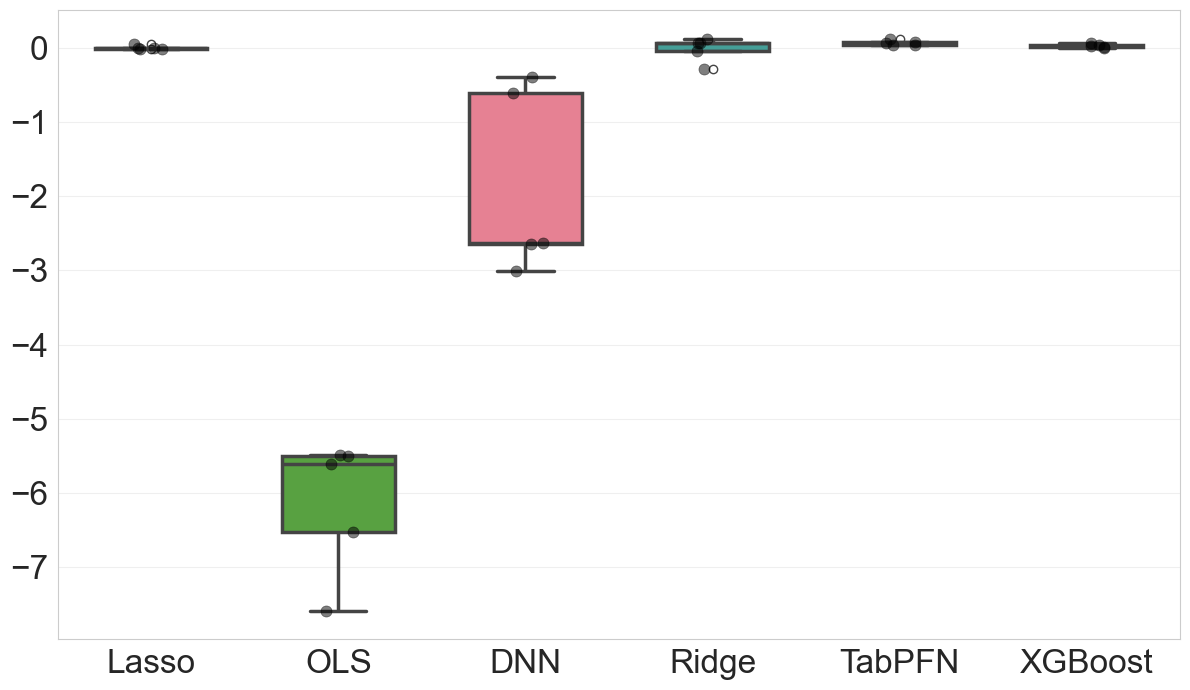

R² Boxplot saved as 'boxplot_r2_by_model.png'


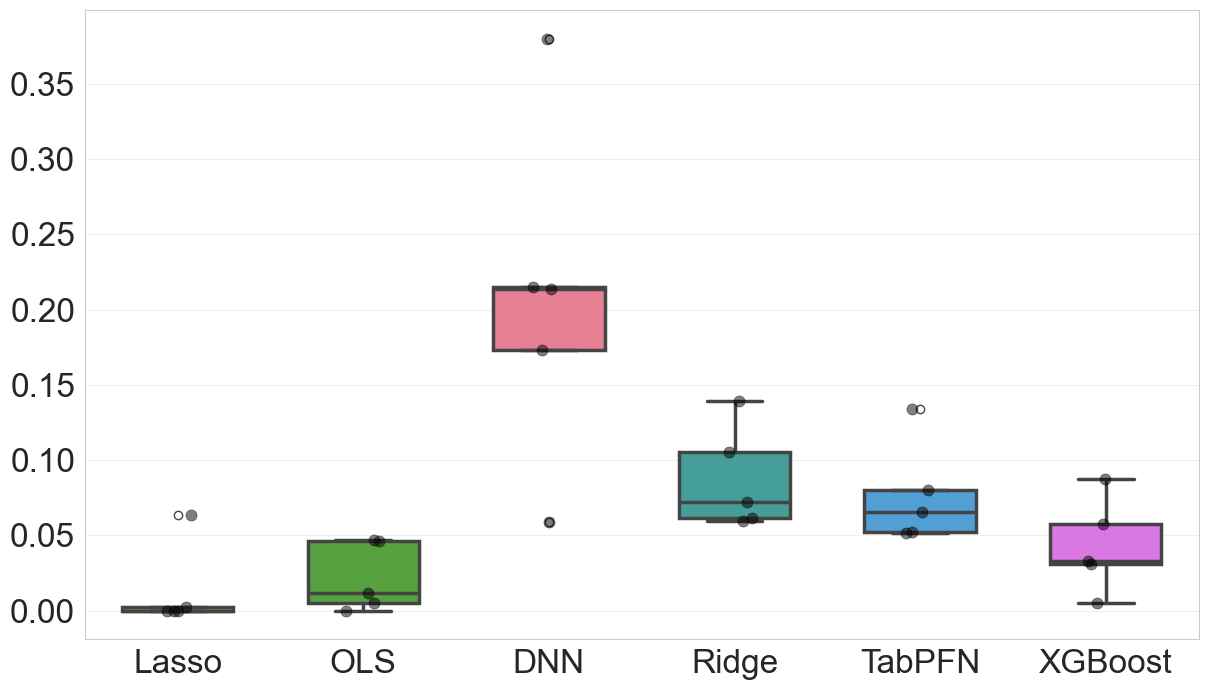

Pearson r² Boxplot saved as 'boxplot_pearson_r2_by_model.png'


In [23]:
# Create separate high-quality boxplots
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Get unique models sorted
models = sorted(df_scores['Model'].unique())

# Color palette for models
colors = sns.color_palette("husl", len(models))
model_colors = {model: colors[i] for i, model in enumerate(models)}

# Plot 1: R² Scores
fig1, ax1 = plt.subplots(figsize=(12, 7))
sns.boxplot(data=df_scores, x='Model', y='R2', ax=ax1, palette=model_colors, width=0.6, linewidth=2.5)
sns.stripplot(data=df_scores, x='Model', y='R2', ax=ax1, color='black', alpha=0.5, size=8, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('', fontsize=18, fontweight='bold')
ax1.set_ylabel('', fontsize=24, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='both', which='major', labelsize=24)
fig1.tight_layout()
plt.savefig('boxplot_r2_by_model.png', dpi=300, bbox_inches='tight')
plt.show()
print("R² Boxplot saved as 'boxplot_r2_by_model.png'")

# Plot 2: Pearson R² Scores
fig2, ax2 = plt.subplots(figsize=(12, 7))
sns.boxplot(data=df_scores, x='Model', y='Pearson_R2', ax=ax2, palette=model_colors, width=0.6, linewidth=2.5)
sns.stripplot(data=df_scores, x='Model', y='Pearson_R2', ax=ax2, color='black', alpha=0.5, size=8, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('', fontsize=18, fontweight='bold')
ax2.set_ylabel('', fontsize=24, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='both', which='major', labelsize=24)
fig2.tight_layout()
plt.savefig('boxplot_pearson_r2_by_model.png', dpi=300, bbox_inches='tight')
plt.show()
print("Pearson r² Boxplot saved as 'boxplot_pearson_r2_by_model.png'")

## 6. Detailed Summary Statistics Table

In [9]:
# Create comprehensive summary table
print("\n" + "=" * 140)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 140)
print()

# Recreate the summary dataframe with more detail
detailed_summary = []
for model in models:
    model_data = df_scores[df_scores['Model'] == model]
    r2_values = model_data['R2'].values
    pearson_r2_values = model_data['Pearson_R2'].values
    
    detailed_summary.append({
        'Model': model,
        'N_Folds': len(r2_values),
        'R2_Mean': r2_values.mean(),
        'R2_Std': r2_values.std(),
        'R2_Min': r2_values.min(),
        'R2_Max': r2_values.max(),
        'Pearson_R2_Mean': pearson_r2_values.mean(),
        'Pearson_R2_Std': pearson_r2_values.std(),
        'Pearson_R2_Min': pearson_r2_values.min(),
        'Pearson_R2_Max': pearson_r2_values.max(),
    })

df_detailed = pd.DataFrame(detailed_summary)

# Format for display
display_df = pd.DataFrame()
display_df['Model'] = df_detailed['Model']
display_df['N'] = df_detailed['N_Folds'].astype(int)
display_df['R² Mean'] = df_detailed['R2_Mean'].apply(lambda x: f"{x:+.6f}")
display_df['R² Std'] = df_detailed['R2_Std'].apply(lambda x: f"{x:.6f}")
display_df['R² Range'] = (df_detailed['R2_Min'].apply(lambda x: f"{x:+.4f}") + ' to ' + 
                          df_detailed['R2_Max'].apply(lambda x: f"{x:+.4f}"))
display_df['Pearson r² Mean'] = df_detailed['Pearson_R2_Mean'].apply(lambda x: f"{x:+.6f}")
display_df['Pearson r² Std'] = df_detailed['Pearson_R2_Std'].apply(lambda x: f"{x:.6f}")
display_df['Pearson r² Range'] = (df_detailed['Pearson_R2_Min'].apply(lambda x: f"{x:+.4f}") + ' to ' + 
                                  df_detailed['Pearson_R2_Max'].apply(lambda x: f"{x:+.4f}"))

print(display_df.to_string(index=False))
print()
print("=" * 140)
print()


COMPREHENSIVE MODEL COMPARISON

       Model  N   R² Mean   R² Std           R² Range Pearson r² Mean Pearson r² Std   Pearson r² Range
       Lasso  7 +0.014232 0.030180 -0.0109 to +0.0617       +0.018874       0.028323 +0.0000 to +0.0636
  Linear Reg  5 -6.146271 0.820694 -7.5928 to -5.4909       +0.022108       0.020495 +0.0000 to +0.0471
Residual DNN  5 -1.853311 1.118890 -3.0093 to -0.3911       +0.208201       0.103143 +0.0586 to +0.3800
       Ridge  5 -0.009873 0.143084 -0.2764 to +0.1268       +0.087527       0.030674 +0.0593 to +0.1392
      TabPFN  5 +0.073727 0.030380 +0.0458 to +0.1299       +0.076573       0.030507 +0.0517 to +0.1339
     XGBoost  5 +0.029356 0.022240 +0.0031 to +0.0663       +0.042673       0.027758 +0.0049 to +0.0872


